### Connecting Google Drive

In [135]:
# Mount Google Drive to access the dataset stored there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importing Required Libraries

In [136]:
# Core libraries for data handling, visualization, and deep learning
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

### Dataset Paths

In [137]:
# Listing files names from Dataset folder
print(os.listdir(dataset_path))

['train', 'test']


In [138]:

# Change these paths after checking your drive folders
train_dir = "/content/drive/MyDrive/Fruits/train"
test_dir = "/content/drive/MyDrive/Fruits/test"

print("Training classes:", len(os.listdir(train_dir)))
print("Some classes:", os.listdir(train_dir)[:10])


Training classes: 5
Some classes: ['Pineapple', 'Apple', 'Strawberry', 'Grapes', 'Orange']


### Load Train Dataset

In [139]:
# Image dimensions and batch size for loading data
img_size = (100,100)
batch_size = 32
# Load training split (80%) from the training directory
# seed=123 ensures the same split every run
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 800 files belonging to 5 classes.
Using 640 files for training.


### Create Validation Dataset

In [140]:
# Load validation split (20%) from the same training directory
# Must use the same seed and split fraction as train_ds to avoid overlap
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 800 files belonging to 5 classes.
Using 160 files for validation.


### Load Test Dataset

In [141]:
# Load the test dataset separately
# shuffle=False is important — keeps order consistent for confusion matrix
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 200 files belonging to 5 classes.


### Get Class Names

In [142]:
# Capture class names BEFORE applying any transformations
# After .map(), the dataset loses the .class_names attribute
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['Apple', 'Grapes', 'Orange', 'Pineapple', 'Strawberry']


### Normalize Images

In [143]:
# Normalize pixel values from [0, 255] to [0.0, 1.0]
# Applied to all three splits for consistency
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y: (normalization_layer(x),y))
val_ds = val_ds.map(lambda x,y: (normalization_layer(x),y))
test_ds = test_ds.map(lambda x,y: (normalization_layer(x),y))


### Show Sample Training Images

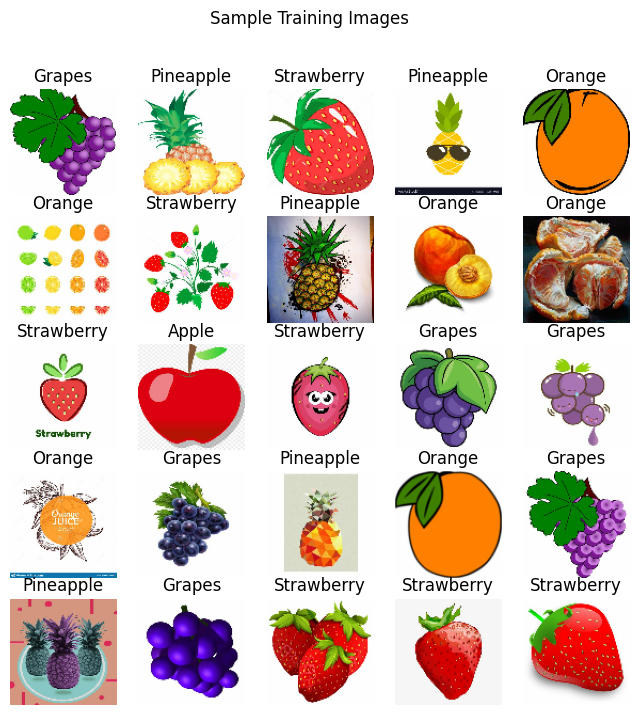

In [144]:
# Visualize a batch of 25 training images with their true class labels
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):

    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.suptitle("Sample Training Images")
plt.show()

### Build CNN Model

In [145]:
# Build a CNN with 3 convolutional blocks + dense head
# Each block: Conv2D → MaxPooling to extract and downsample features
# Dropout(0.5) reduces overfitting by randomly disabling 50% of neurons
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(100,100,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(len(class_names),activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Model Summary

In [146]:
# Print the model architecture: layer names, output shapes, parameter counts
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,421 (6.61 MB)

 Trainable params: 1,732,421 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compile Model

In [147]:
# Compile the model with:
# - Adam optimizer (adaptive learning rate, good default choice)
# - sparse_categorical_crossentropy: correct for integer labels (not one-hot)
# - accuracy as the evaluation metric
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train Model

In [148]:
# Train the model for 10 epochs
# adding EarlyStopping to prevent overfitting on longer runs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 698ms/step - accuracy: 0.2937 - loss: 1.5312 - val_accuracy: 0.4062 - val_loss: 1.3477
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 665ms/step - accuracy: 0.5125 - loss: 1.2244 - val_accuracy: 0.6562 - val_loss: 0.9610
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 730ms/step - accuracy: 0.6422 - loss: 0.9186 - val_accuracy: 0.6687 - val_loss: 0.7435
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 716ms/step - accuracy: 0.6828 - loss: 0.7915 - val_accuracy: 0.7500 - val_loss: 0.6363
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 714ms/step - accuracy: 0.7031 - loss: 0.7331 - val_accuracy: 0.7563 - val_loss: 0.6523
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 730ms/step - accuracy: 0.7609 - loss: 0.6354 - val_accuracy: 0.7937 - val_loss: 0.5495
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 717ms/step - accuracy: 0.7984 - loss: 0.5684 - val_accuracy: 0.8313 - val_loss: 0.4808
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 723ms/step - accuracy: 0.8125 - loss: 0.4903 - val_accu

### Plot Accuracy

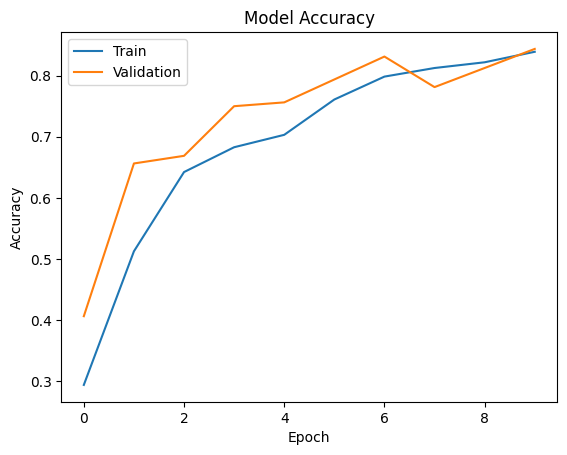

In [149]:
# Plot training vs validation accuracy over epochs
# A large gap means overfitting; both low means underfitting
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

### Plot Loss

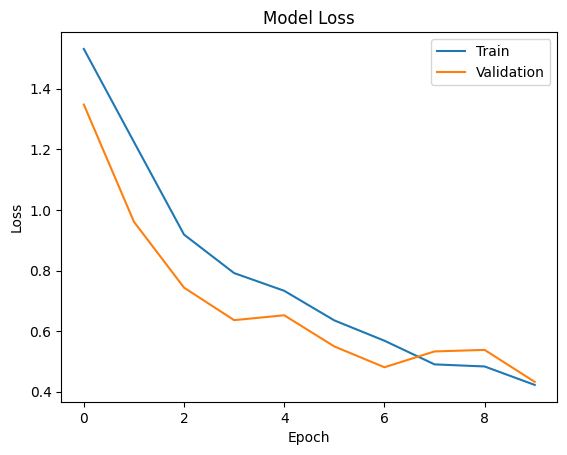

In [150]:
# Plot training vs validation loss over epochs
# Validation loss rising while train loss drops = overfitting signal
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])
plt.show()

In [151]:
# Evaluate the model on unseen test data
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.8350 - loss: 0.4562
Test Accuracy: 0.8349999785423279


### Evaluate Test Dataset

In [152]:
# Minor inefficiency: model.predict() is called once per batch inside the loop
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))
# Build the confusion matrix from collected true and predicted labels
cm = confusion_matrix(y_true,y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


### Confusion Matrix

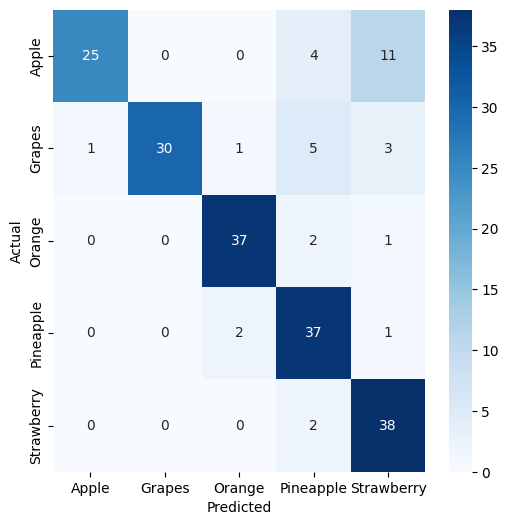

In [153]:
# Visualize confusion matrix as a heatmap
plt.figure(figsize=(6,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Plot matrix:

In [154]:
# Print per-class precision, recall, F1-score, and support
print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

       Apple       0.96      0.62      0.76        40
      Grapes       1.00      0.75      0.86        40
      Orange       0.93      0.93      0.93        40
   Pineapple       0.74      0.93      0.82        40
  Strawberry       0.70      0.95      0.81        40

    accuracy                           0.83       200
   macro avg       0.87      0.83      0.83       200
weighted avg       0.87      0.83      0.83       200



#### Upload Image for Prediction && Predict Uploaded Image

In [155]:
# Upload a single image from your local machine to Colab
from google.colab import files
uploaded = files.upload()

Saving 164_ac06f4ee.jpg to 164_ac06f4ee.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Fruit: Grapes
Confidence: 99.87%


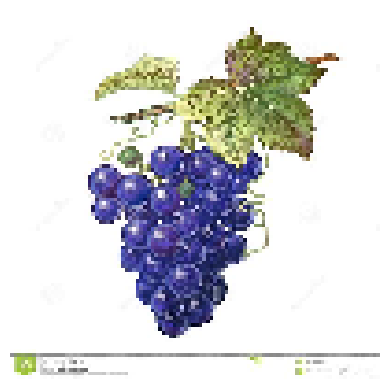

In [156]:
from tensorflow.keras.preprocessing import image
# Load and preprocess the uploaded image to match training input format
import numpy as np
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]
img = image.load_img(img_path, target_size=(100,100))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0
prediction = model.predict(img_array)
confidence = np.max(prediction)
predicted_class = class_names[np.argmax(prediction)]
threshold = 0.75

if confidence < threshold:
    print("Prediction: Unknown object (not in training data)")
else:
    print("Predicted Fruit:", predicted_class)
    print("Confidence: {:.2f}%".format(confidence*100))

plt.imshow(img)
plt.axis("off")
plt.show()